In [2]:
!pip install matplotlib 
!pip install pandas


In [17]:
#Plotting the distribution of the data dictionary
#format {key:count}
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import matplotlib.pyplot as plt
import numpy as np


def plot_distribution(data_dict,
                      rotate_xticks:bool, 
                      x_label:str, 
                      y_label:str, 
                      title:str):

    plt.bar(range(len(data_dict)), list(data_dict.values()), align='center')
    if rotate_xticks:
        plt.xticks(rotation=90, fontsize =7)
    plt.xticks(range(len(data_dict)), list(data_dict.keys()))
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)

    # # for python 2.x:
    # plt.bar(range(len(D)), D.values(), align='center')  # python 2.x
    # plt.xticks(range(len(D)), D.keys())  # in python 2.x

    plt.show()

Total number of songs:  603
Total number of engineers:  10
{'Chris Lord Alge': 13, 'Manny Marroquin': 80, 'Bob Clearmountain': 21, 'Tom Elmhirst': 79, 'Mark Spike Stent': 11, 'Serban Ghenea': 93, 'Josh Gudwin': 83, 'Tony Maserati': 82, 'Jaycen Joshua': 82, 'Dave Pensado': 59}


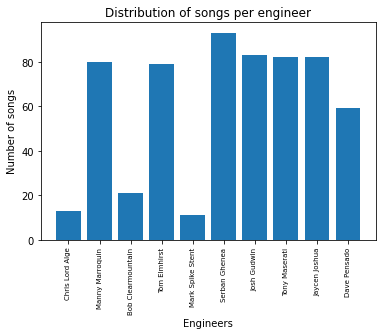

In [18]:
import glob
import os

path = "/import/c4dm-datasets-ext/mix_eng_songs/playlists_wav/"
engineers = glob.glob(path + "*")

songs = []
songs_info = {}
for engineer in engineers:
    songs.extend(glob.glob(engineer + "/*"))
    songs_info[engineer.split("/")[-1]] = len(glob.glob(engineer + "/*"))


print("Total number of songs: ", len(songs))
print("Total number of engineers: ", len(engineers))
print(songs_info)

plot_distribution(songs_info, True, "Engineers", "Number of songs", "Distribution of songs per engineer")



| Engineer | Genre | 
|----------|---------|
|Chris Lord Alge | Pop, Rock|
|Manny Marroquin | Urban, Rock|
|Bob Clearmountain | Pop, Rock |
|Tom Elmhirst| Pop, Rock|
|Mark Spike Stent|  Pop, Rock, R&B, Alternative rock, Electronic|
|Serban Ghenea| Pop,  Hip hop, Electronic| 
|Josh Gudwin| Pop, Latin music|
|Tony Maserati|  R&B, Hip hop|
|Jaycen Joshua| Pop, Urban, Latin music | 
|Dave Pensado | Pop, Rock, R&B|



In [2]:
import pandas as pd
df = pd.read_csv('/homes/ssv02/mix_engineer_style/data/song_features.csv')


In [3]:
df.head()

,Sno,eng_name,songname,momentaryLoudness.mean,shortTermLoudness.mean,integratedLoudness,loudnessRange,pmfSpread,pmfSkewness,pmfKurtosis,...,subBandFlux0.mean,subBandFlux1.mean,subBandFlux2.mean,subBandFlux3.mean,subBandFlux4.mean,subBandFlux5.mean,subBandFlux6.mean,subBandFlux7.mean,subBandFlux8.mean,subBandFlux9.mean
0,0,Chris Lord Alge,In Another Time,-15.392208,-13.570294,-12.099023,6.170374,0.009309,0.050609,1.463678,...,0.140523,0.056202,0.118146,0.102663,0.089456,0.060303,0.036663,0.023242,0.013133,0.003211
1,1,Chris Lord Alge,What's Love Got to Do with It,-15.957800,-14.362834,-12.974639,6.262589,0.005602,0.111830,2.080800,...,0.072204,0.030408,0.060350,0.075360,0.064915,0.062319,0.051076,0.037862,0.022141,0.005639
2,2,Chris Lord Alge,Shake Me Like a Monkey,-8.400035,-7.527917,-7.184124,1.790399,0.019615,0.034258,0.688406,...,0.170621,0.081911,0.148153,0.141530,0.132715,0.122668,0.105837,0.091470,0.067110,0.021643
3,3,Chris Lord Alge,Anxiety,-8.566798,-8.072378,-7.760565,4.708922,0.018064,-0.049210,0.801881,...,0.182068,0.058546,0.129578,0.124621,0.129480,0.115217,0.098796,0.081188,0.057751,0.015882
4,4,Chris Lord Alge,I Can Do Better,-6.581016,-6.362433,-6.302047,2.677061,0.020163,0.007766,0.137012,...,0.168267,0.074160,0.142361,0.135314,0.133896,0.130696,0.138667,0.118568,0.084183,0.021395


In [6]:
Y = df['eng_name']
song_name = df['songname']
X = df[:].drop(['Sno','eng_name','songname'], axis = 1)
columns = X.columns
print(columns)
print(len(columns))

Index(['momentaryLoudness.mean', 'shortTermLoudness.mean',
       'integratedLoudness', 'loudnessRange', 'pmfSpread', 'pmfSkewness',
       'pmfKurtosis', 'pmfCentroid', 'LRImbalance', 'midSideRatio',
       'crest100ms.mean', 'crest1sec.mean', 'panningCoeffs0.mean',
       'panningCoeffs1.mean', 'panningCoeffs2.mean', 'panningCoeffs3.mean',
       'spectralCentroid.mean', 'spectralEntropy.mean',
       'spectralKurtosis.mean', 'spectralRollOff85.mean',
       'spectralRollOff95.mean', 'spectralSkewness.mean',
       'spectralSpread.mean', 'subBandFlux0.mean', 'subBandFlux1.mean',
       'subBandFlux2.mean', 'subBandFlux3.mean', 'subBandFlux4.mean',
       'subBandFlux5.mean', 'subBandFlux6.mean', 'subBandFlux7.mean',
       'subBandFlux8.mean', 'subBandFlux9.mean'],
      dtype='object')
33


In [5]:
#stadard scaling the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)
print(type(scaled_X))



<class 'numpy.ndarray'>


/homes/ssv02/.conda/envs/seprem/lib/python3.10/site-packages/sklearn/utils/validation.py:623: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/homes/ssv02/.conda/envs/seprem/lib/python3.10/site-packages/sklearn/utils/validation.py:623: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():


In [6]:
#PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit_transform(scaled_X)
print(pca.components_)
print(pca.explained_variance_ratio_)


[[-0.24204966 -0.2493246  -0.2859409   0.14997259 -0.26961941 -0.01195415
   0.23218964  0.00280712 -0.01202066  0.05874749  0.11127544  0.14772155
  -0.05311161  0.0236834   0.01863403  0.02857541 -0.00795234 -0.02750511
  -0.01206836  0.05737159  0.01913851  0.03725827 -0.00492795 -0.2246376
  -0.19359184 -0.26542424 -0.2743613  -0.26394066 -0.26471037 -0.25000514
  -0.2486868  -0.23323129 -0.21843116]
 [-0.05882713 -0.04633657 -0.00569353 -0.09134979 -0.08176579  0.0153234
   0.03530296 -0.00431597 -0.03577324 -0.037701    0.22825502  0.06543386
  -0.02521618  0.07428332  0.07479018 -0.03020131  0.36150619  0.36488351
  -0.02952465  0.33886777  0.37106287 -0.32682398  0.2918596  -0.0933736
  -0.10870068 -0.08832402 -0.07896968 -0.05473357  0.00947036  0.11175709
   0.17455272  0.23486238  0.24717982]]
[0.30214248 0.20263055]


In [7]:
#measure the change in variance with number of components
import numpy as np
nums = np.arange(33)
var_ratio = []
for num in nums:
  pca = PCA(n_components=num)
  pca.fit(scaled_X)
  var_ratio.append(np.sum(pca.explained_variance_ratio_))


Text(0.5, 1.0, 'n_components vs. Explained Variance Ratio')

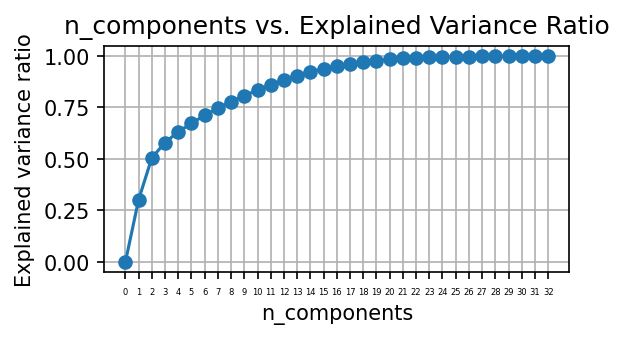

In [8]:
#plot the variance ratio to number of components
import matplotlib.pyplot as plt


plt.figure(figsize=(4,2),dpi=150)
plt.grid()
plt.plot(nums,var_ratio,marker='o')
plt.xticks(np.arange(0, 33, 1))
#reduce the xticks size
plt.xticks(fontsize=4)
plt.xlabel('n_components')
plt.ylabel('Explained variance ratio')
plt.title('n_components vs. Explained Variance Ratio')

In [20]:
#We see that 10 components explain 90% of the variance
pca = PCA(n_components=10)
pca.fit(scaled_X)


<bound method _BasePCA.get_covariance of PCA(n_components=10)>
[[-2.42049659e-01 -2.49324600e-01 -2.85940902e-01  1.49972589e-01
  -2.69619411e-01 -1.19541539e-02  2.32189642e-01  2.80712242e-03
  -1.20206613e-02  5.87474881e-02  1.11275438e-01  1.47721553e-01
  -5.31116141e-02  2.36833968e-02  1.86340318e-02  2.85754133e-02
  -7.95234446e-03 -2.75051148e-02 -1.20683601e-02  5.73715851e-02
   1.91385067e-02  3.72582747e-02 -4.92794978e-03 -2.24637605e-01
  -1.93591843e-01 -2.65424236e-01 -2.74361296e-01 -2.63940664e-01
  -2.64710370e-01 -2.50005143e-01 -2.48686803e-01 -2.33231291e-01
  -2.18431155e-01]
 [-5.88271336e-02 -4.63365688e-02 -5.69352559e-03 -9.13497898e-02
  -8.17657886e-02  1.53234009e-02  3.53029678e-02 -4.31597732e-03
  -3.57732452e-02 -3.77010024e-02  2.28255016e-01  6.54338573e-02
  -2.52161799e-02  7.42833230e-02  7.47901790e-02 -3.02013054e-02
   3.61506192e-01  3.64883506e-01 -2.95246527e-02  3.38867769e-01
   3.71062870e-01 -3.26823980e-01  2.91859605e-01 -9.3373606

In [15]:
#get the variance explained by each component
var = pca.explained_variance_ratio_
variance = {}
#print(var)
print("Variance explained by component ")
for i in range(len(var)):
    variance[columns[i]] = var[i]
    #print(columns[i], " is ", var[i])
variance = dict(sorted(variance.items(), key=lambda item: item[1], reverse=True))
print(variance)

Variance explained by component 
{'momentaryLoudness.mean': 0.3021424807625271, 'shortTermLoudness.mean': 0.2026305519344801, 'integratedLoudness': 0.07427542280253153, 'loudnessRange': 0.05230420855182849, 'pmfSpread': 0.040698435068903305, 'pmfSkewness': 0.03935360926414978, 'pmfKurtosis': 0.03549221971390565, 'pmfCentroid': 0.031010163866939475, 'LRImbalance': 0.028843587891750108, 'midSideRatio': 0.02754245073605834, 'crest100ms.mean': 0.026266992417314318, 'crest1sec.mean': 0.022936511205800855, 'panningCoeffs0.mean': 0.01978489873290186, 'panningCoeffs1.mean': 0.018873667532777347, 'panningCoeffs2.mean': 0.015169265183189508, 'panningCoeffs3.mean': 0.013033502860726999, 'spectralCentroid.mean': 0.011029467745204809, 'spectralEntropy.mean': 0.008189070723188552, 'spectralKurtosis.mean': 0.007521176430526013, 'spectralRollOff85.mean': 0.006671227636216431, 'spectralRollOff95.mean': 0.0035134359106206554, 'spectralSkewness.mean': 0.0030617416649572514, 'spectralSpread.mean': 0.00240

ConversionError: Failed to convert value(s) to axis units: Index(['momentaryLoudness.mean', 'shortTermLoudness.mean',
       'integratedLoudness', 'loudnessRange', 'pmfSpread', 'pmfSkewness',
       'pmfKurtosis', 'pmfCentroid', 'LRImbalance', 'midSideRatio',
       'crest100ms.mean', 'crest1sec.mean', 'panningCoeffs0.mean',
       'panningCoeffs1.mean', 'panningCoeffs2.mean', 'panningCoeffs3.mean',
       'spectralCentroid.mean', 'spectralEntropy.mean',
       'spectralKurtosis.mean', 'spectralRollOff85.mean',
       'spectralRollOff95.mean', 'spectralSkewness.mean',
       'spectralSpread.mean', 'subBandFlux0.mean', 'subBandFlux1.mean',
       'subBandFlux2.mean', 'subBandFlux3.mean', 'subBandFlux4.mean',
       'subBandFlux5.mean', 'subBandFlux6.mean', 'subBandFlux7.mean',
       'subBandFlux8.mean', 'subBandFlux9.mean'],
      dtype='object')

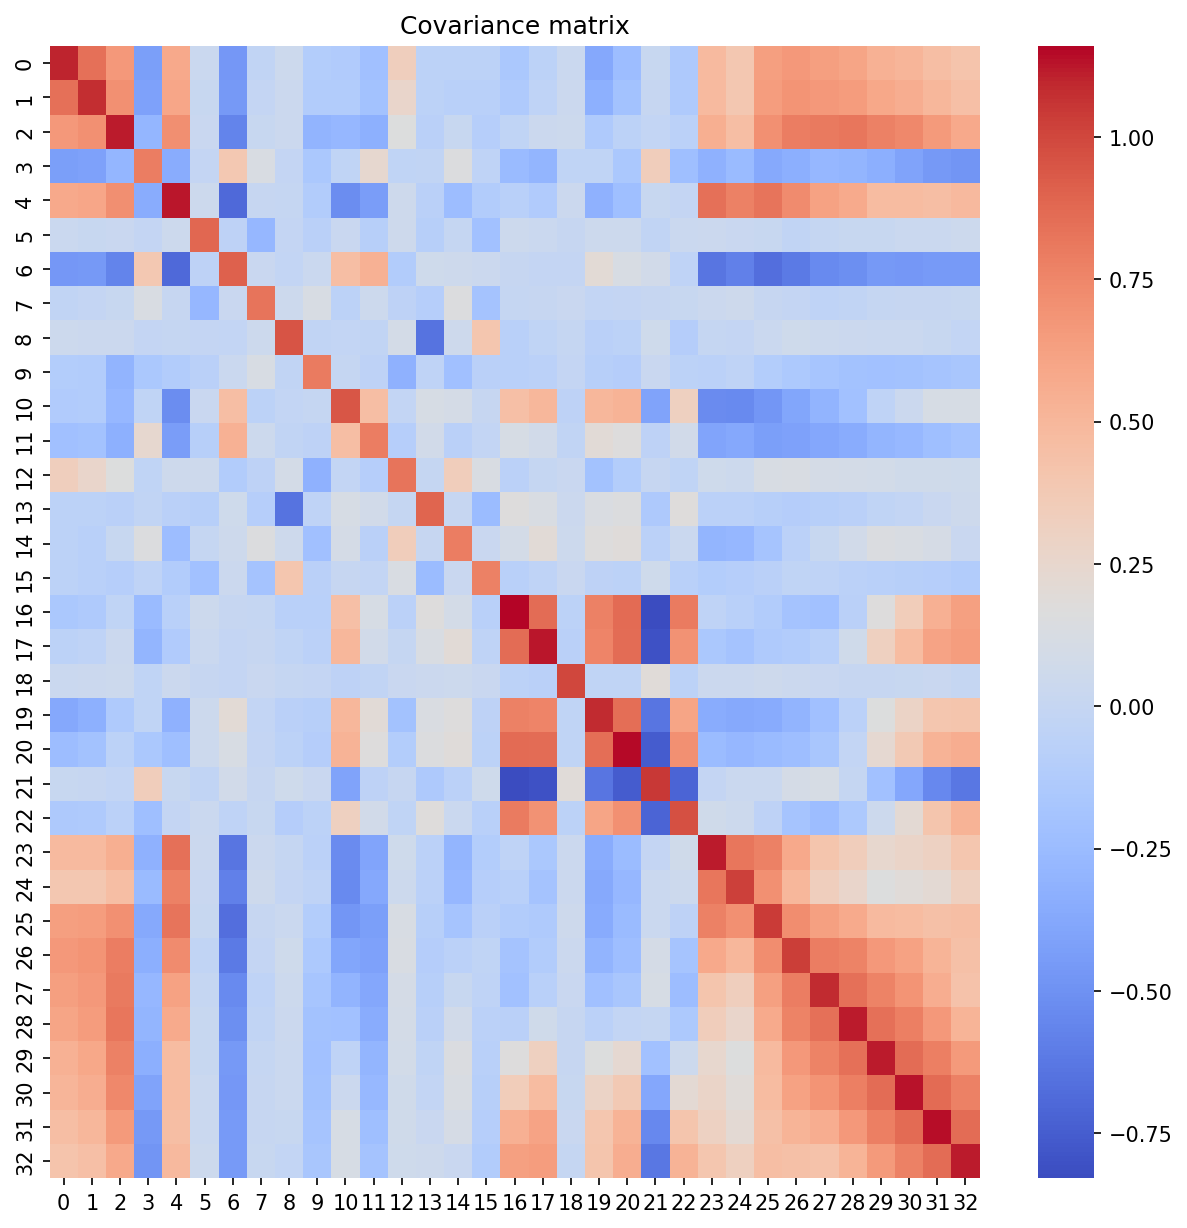

In [25]:


#plot the covariance matrix
import seaborn as sns
plt.figure(figsize=(10,10),dpi=150)
sns.heatmap(pca.get_covariance(),cmap='coolwarm')
plt.title('Covariance matrix')
plt.xticks(columns,rotation=90)
plt.yticks(columns,rotation=0)


| Feature Type       | Name              | Description                                  | Use                                          | Range            |
|--------------------|-------------------|----------------------------------------------|----------------------------------------------|------------------|
| Time-domain features | RMS               | Root Mean Square (RMS) loudness calculation. | Provides a measure of loudness.               | Positive floating point. |
|                    | ZCR               | Zero-Crossing Rate (ZCR) computation.        | Helps differentiate between percussive and pitched sounds. | Range from 0 to 255 (default buffer size 512). |
|                    | Energy            | Integral of squared signal over time.        | Offers an indicator of loudness.             | Range from 0 to bufferSize. |
| Spectral Features   | AmplitudeSpectrum | Magnitude spectrum obtained via FFT.         | Useful for general audio analysis.           | Array, range from 0 to half of FFT size. |
|                    | Power Spectrum    | Square of the Amplitude Spectrum.            | Enhances frequency difference perception.    | Array, range from 0 to half of FFT size. |
|                    | Spectral Centroid | Spectral center of gravity for brightness.   | Helps distinguish the brightness of a sound. | Range from 0 to half of FFT size. |
|                    | Spectral Flatness | Spectrum flatness ratio calculation.         | Indicates the noisiness of a sound.         | Range from 0.0 to 1.0. |
|                    | Spectral Flux     | Rate of change in the spectrum.             | Corresponds to perceptual sound roughness.    | Starts at 0.0, no upper limit. |
|                    | Spectral Slope    | Inclination measure of the spectrum.        | Differentiates various voice qualities.      | Range from 0.0 to 1.0. |
|                    | Spectral Rolloff  | Frequency containing 99% of energy.         | Approximates the maximum frequency.          | Range from 0 to half of sampling rate. |
|                    | Spectral Spread   | Indicator of frequency content spread.       | Helps distinguish noisy from pitched sounds. | Range from 0 to half of FFT size. |
|                    | Spectral Skewness | Measure of spectrum skewness.               | Provides insight into the timbre of a sound. | Can be negative, positive, or 0. |
|                    | Spectral Kurtosis | Indicator of spectrum pointiness.           | Assesses the pitchiness or tonality.        | Range from 0.0 to 1.0. |
|                    | Spectral Crest    | Ratio of peak magnitude to RMS.             | Evaluates peakiness in the spectrum.        | Arbitrary range with higher values indicating more extreme peaks. |
|                    | Chroma            | Chromatic pitch class presence.             | Useful for analyzing harmonic content.       | Range from 0.0 to 1.0 for each pitch class. |
| Perceptual features | Loudness          | Loudness perception using Bark Scale.        | Reflects human loudness perception.          | User-defined range. |
|                    | Perceptual Spread | Spread of loudness coefficients.            | Indicates richness or fullness of a sound.   | Range from 0.0 to 1.0. |
|                    | Perceptual Sharpness | Sharpness perception based on Bark loudness coefficients. | Detects perceived sharpness. | Range from 0.0 to 1.0. |
|                    | MFCC              | Mel-Frequency Cepstral Coefficients.        | Often used for voice activity detection and ASR preparation. | Array, user-defined size. |

|   |   |   |
|---|---|---|
|Category|Feature|Reference|
|Dynamic|Loudness  <br>Crest factor (100 ms and 1 s) Activity|[3, 12] [17] [7]|
|Spatial|SPS<br><br>P[band]  <br>Side/mid ratio Left/right imbalance|[16] [16]|
|Spectral|Centroid  <br>Brightness  <br>Spread  <br>Skewness  <br>Kurtosis  <br>Rolloff (.95 and .85) Entropy<br><br>Flatness  <br>Roughness Irregularity Zero-crossing rate Low energy  <br>Octave band energies|[5]<br><br>· ·<br><br>[5]|



In [85]:
fig, axs = plt.subplots(3, 11, figsize=(220, 60))
i = 0
j = 0
for columns in X.columns:
    sns.kdeplot(data = X[columns] , ax = axs[i,j], fill =True, linewidth = 0.7)
    axs[i,j].set_title(columns)
    i = i+1
    if i%3 == 0:
        i = 0
        j = j+1
plt.show()

In [48]:
eng_labels = Y.unique()
print(eng_labels)

['Chris Lord Alge' 'Manny Marroquin' 'Bob Clearmountain' 'Tom Elmhirst'
 'Mark Spike Stent' 'Serban Ghenea' 'Josh Gudwin' 'Tony Maserati'
 'Jaycen Joshua' 'Dave Pensado']


In [7]:
#normalise the feature between 0 and 1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
print(X.shape)
#turn X into a dataframe
X = pd.DataFrame(X)
X.columns = columns
print(X.head())


(603, 33)
   momentaryLoudness.mean  shortTermLoudness.mean  integratedLoudness  \
0                0.861862                0.876736            0.619589   
1                0.852994                0.863688            0.573078   
2                0.971482                0.976213            0.880658   
3                0.968868                0.967249            0.850039   
4                1.000000                0.995400            0.927512   

   loudnessRange  pmfSpread  pmfSkewness  pmfKurtosis  pmfCentroid  \
0       0.248485   0.146464     0.728215     0.316872     0.290913   
1       0.252744   0.084342     0.815193     0.399754     0.290968   
2       0.046172   0.319151     0.704985     0.212750     0.295404   
3       0.180980   0.293177     0.586401     0.227990     0.297376   
4       0.087128   0.328339     0.667348     0.138695     0.285521   

   LRImbalance  midSideRatio  ...  subBandFlux0.mean  subBandFlux1.mean  \
0     0.309041      0.007291  ...           0.188340   

/homes/ssv02/.conda/envs/seprem/lib/python3.10/site-packages/sklearn/utils/validation.py:623: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/homes/ssv02/.conda/envs/seprem/lib/python3.10/site-packages/sklearn/utils/validation.py:623: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():


In [ ]:
#Plotting the scatter matrix of the data dictionary
import plotly.express as px
import plotly.graph_objects as go

fig = px.scatter_matrix(X, dimensions=columns, color=Y)
fig.update_traces(diagonal_visible=False)

# rotate axis labels
fig.update_xaxes()


# fig.update_xaxes(tickangle=-90)
# fig.update_yaxes(tickangle=auto)
fig.update_layout(
    title='Features Scatter Matrix',
    width=6600,
    height=6600,
)



#save the figure
#fig.write_image("scatter_matrix.png")

fig.show()


In [8]:
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 KB 4.7 MB/s eta 0:00:00a 0:00:01


Text(0.5, 0, 'momentaryLoudness.mean')

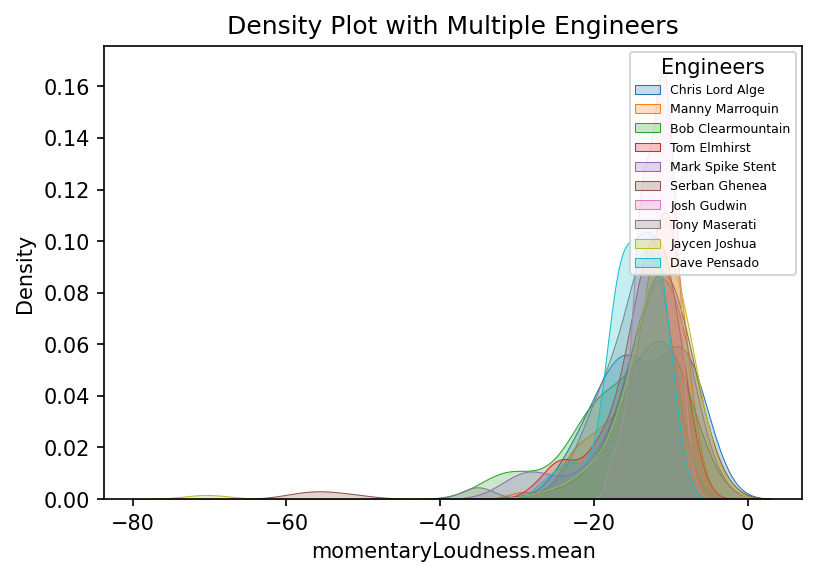

In [86]:
# plotting the distribution of the loudness of the songs by engineers
import seaborn as sns
for eng in eng_labels:
    subset= df[df['eng_name'] == eng]
    subset_name = eng
    #pick only firt 15 songs
    #subset = subset[:11]
    
    # Draw the density plot
    sns.kdeplot(subset['momentaryLoudness.mean'], fill =True, label = subset_name, linewidth = 0.5)

    
    
    
# Plot formatting

plt.legend(prop={'size': 6}, title = 'Engineers')
plt.title('Density Plot with Multiple Engineers')
plt.xlabel('momentaryLoudness.mean')



Text(0.5, 0, 'loudnessRange')

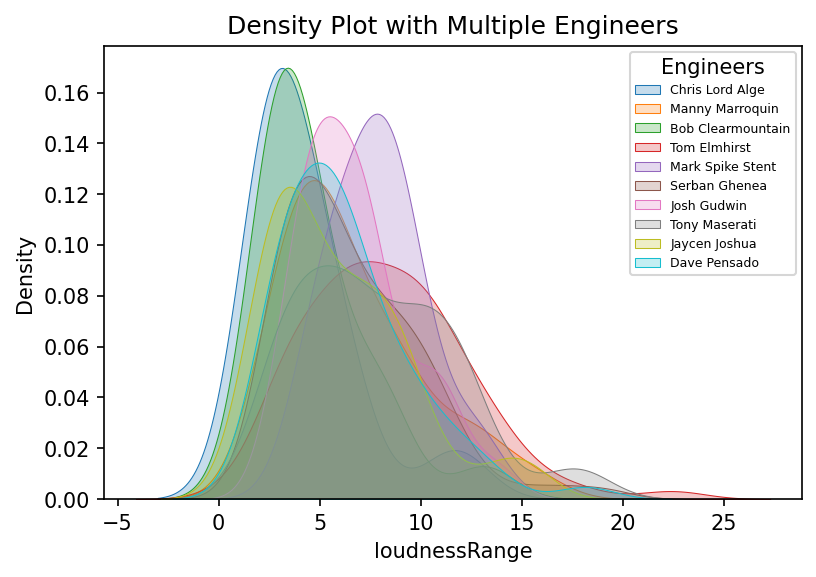

In [87]:
# plotting the distribution of the loudness of the songs by engineers
import seaborn as sns
for eng in eng_labels:
    subset= df[df['eng_name'] == eng]
    subset_name = eng
    #pick only firt 15 songs
    #subset = subset[:11]
    
    # Draw the density plot
    
    sns.kdeplot(subset['loudnessRange'], fill = True , label = subset_name, linewidth = 0.5)
    
    
    
# Plot formatting

plt.legend(prop={'size': 6}, title = 'Engineers')
plt.title('Density Plot with Multiple Engineers')
plt.xlabel('loudnessRange')



Text(0.5, 0, 'spectralCentroid.mean')

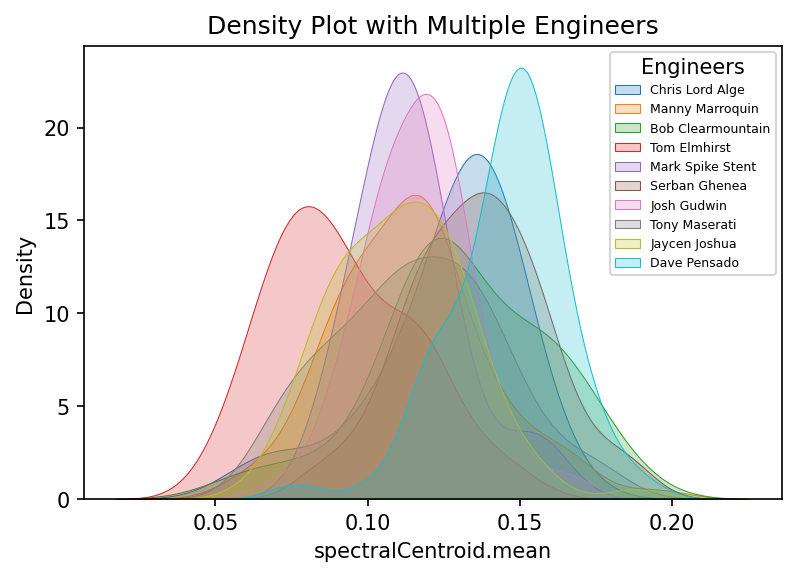

In [93]:
import seaborn as sns
for eng in eng_labels:
    subset= df[df['eng_name'] == eng]
    subset_name = eng
    #pick only firt 15 songs
    #subset = subset[:11]
    
    # Draw the density plot
    
    sns.kdeplot(subset['spectralCentroid.mean'] , fill = True, label = subset_name, linewidth = 0.5)
    
    
    
# Plot formatting

plt.legend(prop={'size': 6}, title = 'Engineers')
plt.title('Density Plot with Multiple Engineers')
plt.xlabel('spectralCentroid.mean')


In [1]:
X.head()
Y.head()

NameError: name 'X' is not defined

metrics: silhouette (for seperability and compactness of cluster)
inter and intra cluster distribution and distances
how good clustering is

optimise feature selection


embedding:
I can add more labels



#eras

